In [1]:
# ============================================================
# CELL 1: Import Libraries & Cek Environment
# ============================================================
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from PIL import Image
from pathlib import Path
import torch
import warnings
warnings.filterwarnings('ignore')

# --- Cek GPU / CUDA ---
print("=" * 50)
print("  ENVIRONMENT CHECK")
print("=" * 50)
print(f"PyTorch Version  : {torch.__version__}")
print(f"CUDA Available   : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU Name         : {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version     : {torch.version.cuda}")
    gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU Memory       : {gpu_mem:.1f} GB")
else:
    print("GPU              : Tidak terdeteksi, menggunakan CPU")

print("=" * 50)
print("✅ Semua library berhasil diimport!")

  ENVIRONMENT CHECK
PyTorch Version  : 2.7.1+cu118
CUDA Available   : True
GPU Name         : NVIDIA GeForce RTX 3050 Laptop GPU
CUDA Version     : 11.8
GPU Memory       : 4.3 GB
✅ Semua library berhasil diimport!


In [2]:
# ============================================================
# CELL2: Setup & Verifikasi Path Direktori
# ============================================================
from pathlib import Path

# Notebook ada di notebooks/, jadi naik 1 level ke root proyek
BASE_DIR  = Path("..").resolve()  # Gunakan absolute path untuk menghindari error path
DATA_DIR  = BASE_DIR / "data"

DATA_TRAIN_IMG = DATA_DIR / "train" / "images"
DATA_TRAIN_LBL = DATA_DIR / "train" / "labels"
DATA_VALID_IMG = DATA_DIR / "valid" / "images"
DATA_VALID_LBL = DATA_DIR / "valid" / "labels"
DATA_TEST_IMG  = DATA_DIR / "test"  / "images"
DATA_TEST_LBL  = DATA_DIR / "test"  / "labels"
YAML_PATH      = DATA_DIR / "data.yaml"

# Verifikasi semua folder ada
paths_to_check = {
    "data/train/images": DATA_TRAIN_IMG,
    "data/train/labels": DATA_TRAIN_LBL,
    "data/valid/images": DATA_VALID_IMG,
    "data/valid/labels": DATA_VALID_LBL,
    "data/test/images" : DATA_TEST_IMG,
    "data/test/labels" : DATA_TEST_LBL,
    "data/data.yaml"   : YAML_PATH,
}

print("📁 VERIFIKASI STRUKTUR DIREKTORI:")
print("=" * 45)
all_ok = True
for label, path in paths_to_check.items():
    exists = path.exists()
    status = "✅" if exists else "❌ TIDAK DITEMUKAN"
    print(f"  {status}  {label}")
    if not exists:
        all_ok = False

print("=" * 45)
if all_ok:
    print("✅ Semua path ditemukan. Siap lanjut!")
else:
    print("⚠️  Ada path yang tidak ditemukan. Cek struktur folder kamu.")

📁 VERIFIKASI STRUKTUR DIREKTORI:
  ✅  data/train/images
  ✅  data/train/labels
  ✅  data/valid/images
  ✅  data/valid/labels
  ✅  data/test/images
  ✅  data/test/labels
  ✅  data/data.yaml
✅ Semua path ditemukan. Siap lanjut!


In [3]:
# ============================================================
# CELL 3: Baca & Tampilkan data.yaml
# ============================================================
import yaml

with open(YAML_PATH, 'r') as f:
    data_cfg = yaml.safe_load(f)

print("📄 ISI data.yaml:")
print("=" * 40)
for k, v in data_cfg.items():
    print(f"  {k}: {v}")
print("=" * 40)

# Ambil nama kelas dari yaml
CLASS_NAMES = {i: name for i, name in enumerate(data_cfg.get('names', []))}
print(f"\n🏷️  Kelas terdeteksi ({len(CLASS_NAMES)} kelas):")
for idx, name in CLASS_NAMES.items():
    print(f"   [{idx}] {name}")

📄 ISI data.yaml:
  path: D:\cv-posture\data
  train: train/images
  val: valid/images
  test: test/images
  nc: 3
  names: ['Good Posture', 'Mild Fatigue', 'Bad Posture']
  kpt_shape: [17, 3]

🏷️  Kelas terdeteksi (3 kelas):
   [0] Good Posture
   [1] Mild Fatigue
   [2] Bad Posture


📊 DATASET SUMMARY
  Train  :  4034 gambar
  Valid  :   282 gambar
  Test   :    47 gambar
  ──────────────────────────────
  Total  :  4363 gambar


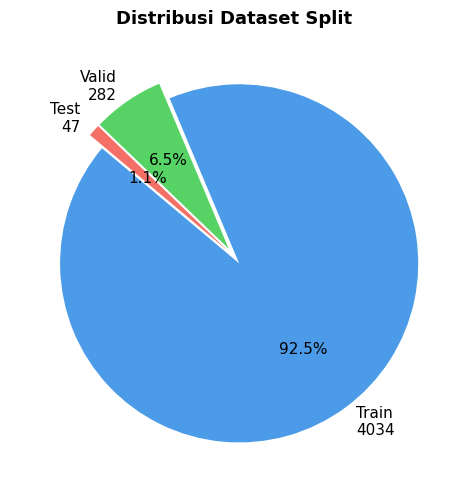

In [4]:
# ============================================================
# CELL 4: itung Dataset & Visualisasi Split
# ============================================================
import matplotlib.pyplot as plt

def count_files(path, exts=('.jpg', '.jpeg', '.png')):
    return sum(1 for f in Path(path).glob('*') if f.suffix.lower() in exts)

train_count = count_files(DATA_TRAIN_IMG)
valid_count = count_files(DATA_VALID_IMG)
test_count  = count_files(DATA_TEST_IMG)
total       = train_count + valid_count + test_count

print("📊 DATASET SUMMARY")
print("=" * 40)
print(f"  Train  : {train_count:>5} gambar")
print(f"  Valid  : {valid_count:>5} gambar")
print(f"  Test   : {test_count:>5} gambar")
print(f"  {'─'*30}")
print(f"  Total  : {total:>5} gambar")
print("=" * 40)

# Pie chart distribusi split
fig, ax = plt.subplots(figsize=(5, 5))
sizes  = [train_count, valid_count, test_count]
labels = [f'Train\n{train_count}', f'Valid\n{valid_count}', f'Test\n{test_count}']
colors = ['#4C9BE8', '#56d364', '#f47067']
ax.pie(sizes, labels=labels, colors=colors, explode=(0.05, 0.05, 0.05),
       autopct='%1.1f%%', startangle=140, textprops={'fontsize': 11})
ax.set_title('Distribusi Dataset Split', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

✅ Total anotasi terbaca: 3935
   Jumlah gambar berlabel: 3878
   Kelas ditemukan: [2 1]



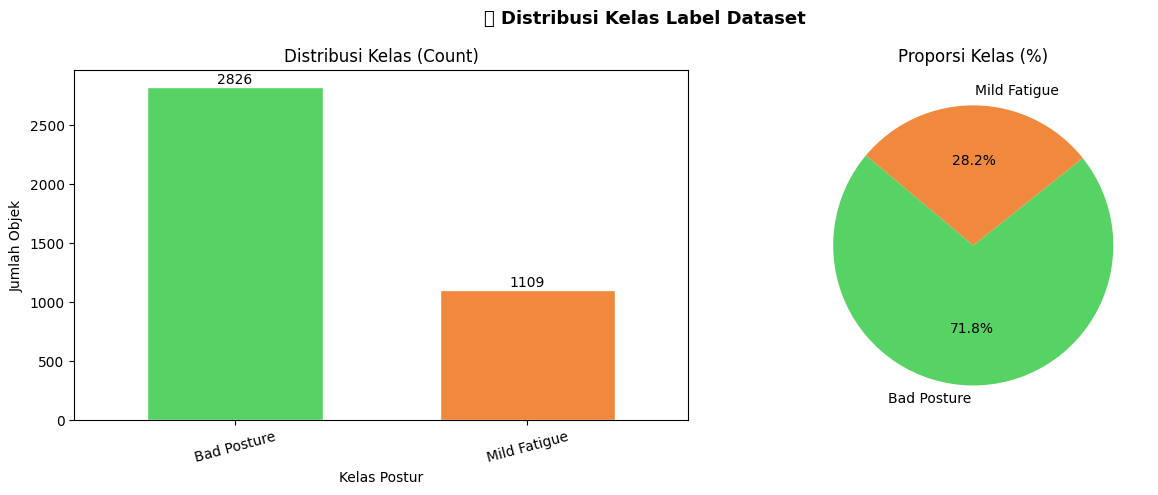

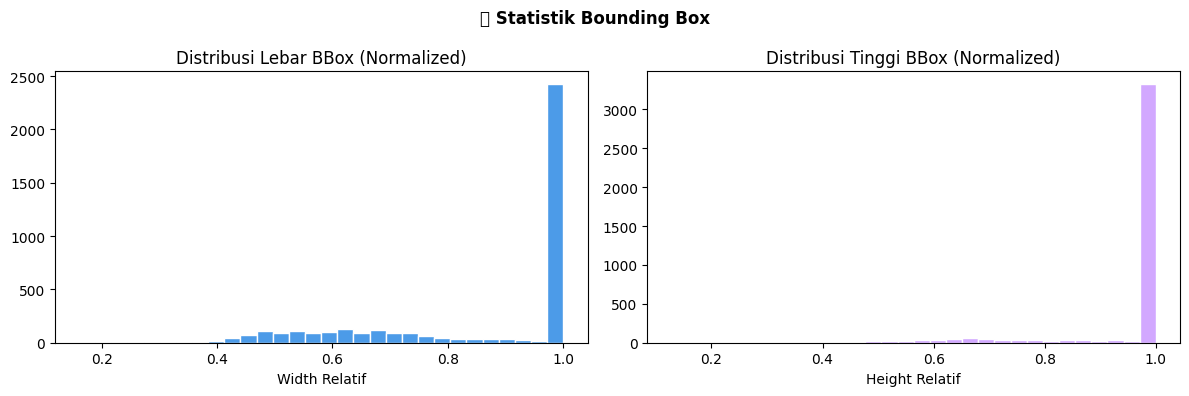


📋 RINGKASAN LABEL PER KELAS:
                area                                                width                                               height                                           
               count   mean    std    min    25%    50%  75%  max   count   mean    std    min    25%    50%  75%  max   count   mean    std    min    25%  50%  75%  max
class_name                                                                                                                                                               
Bad Posture   2826.0  0.865  0.225  0.033  0.719  1.000  1.0  1.0  2826.0  0.888  0.189  0.161  0.760  1.000  1.0  1.0  2826.0  0.961  0.113  0.203  1.000  1.0  1.0  1.0
Mild Fatigue  1109.0  0.724  0.251  0.026  0.536  0.681  1.0  1.0  1109.0  0.773  0.217  0.205  0.589  0.769  1.0  1.0  1109.0  0.922  0.162  0.128  0.978  1.0  1.0  1.0


In [5]:
# ============================================================
# CELL 5: Eksplorasi Label & Distribusi Kelas
# ============================================================

# Sesuaikan nama kelas dengan dataset kamu
# Contoh untuk dataset posture (3 kelas):
CLASS_NAMES = {
    0: "Good Posture",
    1: "Mild Fatigue",
    2: "Bad Posture"
}
# Jika dataset kamu berbeda, ubah CLASS_NAMES di sini

def parse_yolo_labels(label_folder):
    """Baca semua file label YOLO dan kembalikan sebagai DataFrame."""
    records = []
    for lbl_path in Path(label_folder).glob('*.txt'):
        with open(lbl_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    cls_id = int(parts[0])
                    cx, cy, w, h = map(float, parts[1:5])
                    records.append({
                        'file': lbl_path.stem,
                        'class_id': cls_id,
                        'class_name': CLASS_NAMES.get(cls_id, f"class_{cls_id}"),
                        'cx': cx, 'cy': cy,
                        'width': w, 'height': h,
                        'area': w * h
                    })
    return pd.DataFrame(records)

df_labels = parse_yolo_labels(DATA_TRAIN_LBL)

if df_labels.empty:
    print("⚠️  Tidak ada label ditemukan. Pastikan folder labels sudah terisi.")
else:
    print(f"✅ Total anotasi terbaca: {len(df_labels)}")
    print(f"   Jumlah gambar berlabel: {df_labels['file'].nunique()}")
    print(f"   Kelas ditemukan: {df_labels['class_id'].unique()}")
    print()

    # --- 1. Distribusi Kelas ---
    class_counts = df_labels['class_name'].value_counts()

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    colors = ['#56d364', '#f0883e', '#f47067']

    class_counts.plot(kind='bar', ax=axes[0], color=colors[:len(class_counts)],
                      edgecolor='white', width=0.6)
    axes[0].set_title('Distribusi Kelas (Count)', fontsize=12)
    axes[0].set_xlabel('Kelas Postur'); axes[0].set_ylabel('Jumlah Objek')
    axes[0].tick_params(axis='x', rotation=15)
    for bar in axes[0].patches:
        axes[0].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 1, str(int(bar.get_height())),
                     ha='center', va='bottom', fontsize=10)

    axes[1].pie(class_counts, labels=class_counts.index,
                autopct='%1.1f%%', colors=colors[:len(class_counts)],
                startangle=140, textprops={'fontsize': 10})
    axes[1].set_title('Proporsi Kelas (%)', fontsize=12)

    plt.suptitle("🏷️ Distribusi Kelas Label Dataset", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # --- 2. Distribusi Ukuran Bounding Box ---
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(df_labels['width'], bins=30, color='#4C9BE8', edgecolor='white')
    axes[0].set_title('Distribusi Lebar BBox (Normalized)')
    axes[0].set_xlabel('Width Relatif')

    axes[1].hist(df_labels['height'], bins=30, color='#d2a8ff', edgecolor='white')
    axes[1].set_title('Distribusi Tinggi BBox (Normalized)')
    axes[1].set_xlabel('Height Relatif')

    plt.suptitle("📦 Statistik Bounding Box", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # --- 3. Tabel Ringkasan ---
    print("\n📋 RINGKASAN LABEL PER KELAS:")
    print(df_labels.groupby('class_name')[['area', 'width', 'height']]
          .describe().round(3).to_string())

In [6]:
# ============================================================
# CELL 6: Generate File data.yaml (Konfigurasi YOLO)
# ============================================================
import yaml

data_yaml = {
    'path': str(BASE_DIR / "data"),
    'train': 'train/images',
    'val':   'valid/images',
    'test':  'test/images',
    'nc':    len(CLASS_NAMES),
    'names': list(CLASS_NAMES.values())
}

yaml_path = BASE_DIR / "data" / "data.yaml"
with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f, default_flow_style=False, sort_keys=False)

# Tampilkan isi yaml
print("📄 ISI FILE data.yaml:")
print("=" * 40)
with open(yaml_path) as f:
    print(f.read())
print("=" * 40)
print(f"✅ Tersimpan di: {yaml_path}")

📄 ISI FILE data.yaml:
path: D:\cv-posture\data
train: train/images
val: valid/images
test: test/images
nc: 3
names:
- Good Posture
- Mild Fatigue
- Bad Posture

✅ Tersimpan di: D:\cv-posture\data\data.yaml


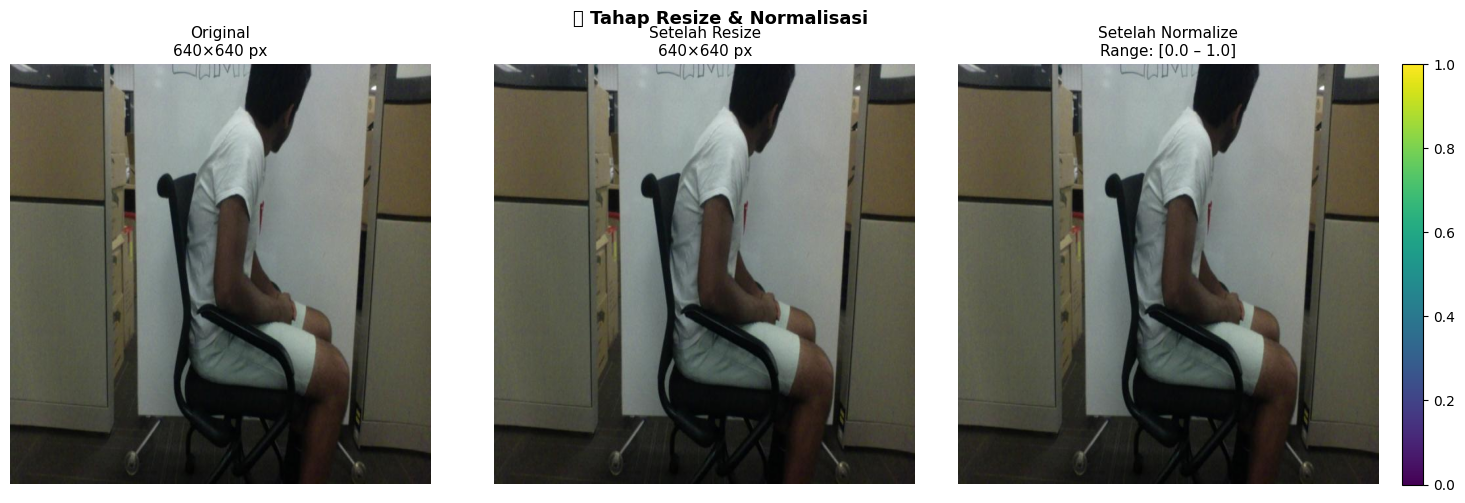


📊 STATISTIK PIXEL:
     Stage         Shape  Min   Max    Mean     Std
  Original (640, 640, 3)  0.0 255.0 84.2600 49.6200
   Resized (640, 640, 3)  0.0 255.0 84.2600 49.6200
Normalized (640, 640, 3)  0.0   1.0  0.3304  0.1946


In [7]:
# ============================================================
# CELL 7: Preprocessing — Resize & Normalize (Visualisasi)
# ============================================================
from torchvision import transforms

TARGET_SIZE = 640   # YOLOv8 default input size


def load_images_from(image_dir, exts=('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'), max_samples=None):
    """Ambil list file gambar dari folder, urutkan secara alfabet."""
    image_dir = Path(image_dir)
    if not image_dir.exists() or not image_dir.is_dir():
        return []
    imgs = [p for p in sorted(image_dir.iterdir()) if p.suffix.lower() in exts]
    return imgs[:max_samples] if max_samples else imgs

# Gunakan gambar spesifik dari path yang diberikan
img_path = Path("../data/train/images/23_jpg.rf.9a29da4aa37ea782bd677c76966bdfb6.jpg")
if not img_path.exists():
    print("⚠️  Gambar tidak ditemukan di path yang ditentukan.")
else:
    img_orig  = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    
    # Resize
    img_resized = cv2.resize(img_orig, (TARGET_SIZE, TARGET_SIZE))

    # Normalize ke [0, 1]
    img_norm = img_resized.astype(np.float32) / 255.0

    # Tampilkan perbandingan
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(img_orig)
    axes[0].set_title(f"Original\n{img_orig.shape[1]}×{img_orig.shape[0]} px", fontsize=11)
    axes[0].axis('off')

    axes[1].imshow(img_resized)
    axes[1].set_title(f"Setelah Resize\n{TARGET_SIZE}×{TARGET_SIZE} px", fontsize=11)
    axes[1].axis('off')

    im = axes[2].imshow(img_norm)
    axes[2].set_title(f"Setelah Normalize\nRange: [0.0 – 1.0]", fontsize=11)
    axes[2].axis('off')
    plt.colorbar(im, ax=axes[2], fraction=0.046)

    plt.suptitle("🖼️ Tahap Resize & Normalisasi", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Statistik pixel
    print("\n📊 STATISTIK PIXEL:")
    df_pixel = pd.DataFrame({
        'Stage':    ['Original', 'Resized', 'Normalized'],
        'Shape':    [str(img_orig.shape), str(img_resized.shape), str(img_norm.shape)],
        'Min':      [img_orig.min(), img_resized.min(), round(img_norm.min(), 4)],
        'Max':      [img_orig.max(), img_resized.max(), round(img_norm.max(), 4)],
        'Mean':     [round(img_orig.mean(), 2), round(img_resized.mean(), 2), round(img_norm.mean(), 4)],
        'Std':      [round(img_orig.std(), 2), round(img_resized.std(), 2), round(img_norm.std(), 4)],
    })
    print(df_pixel.to_string(index=False))

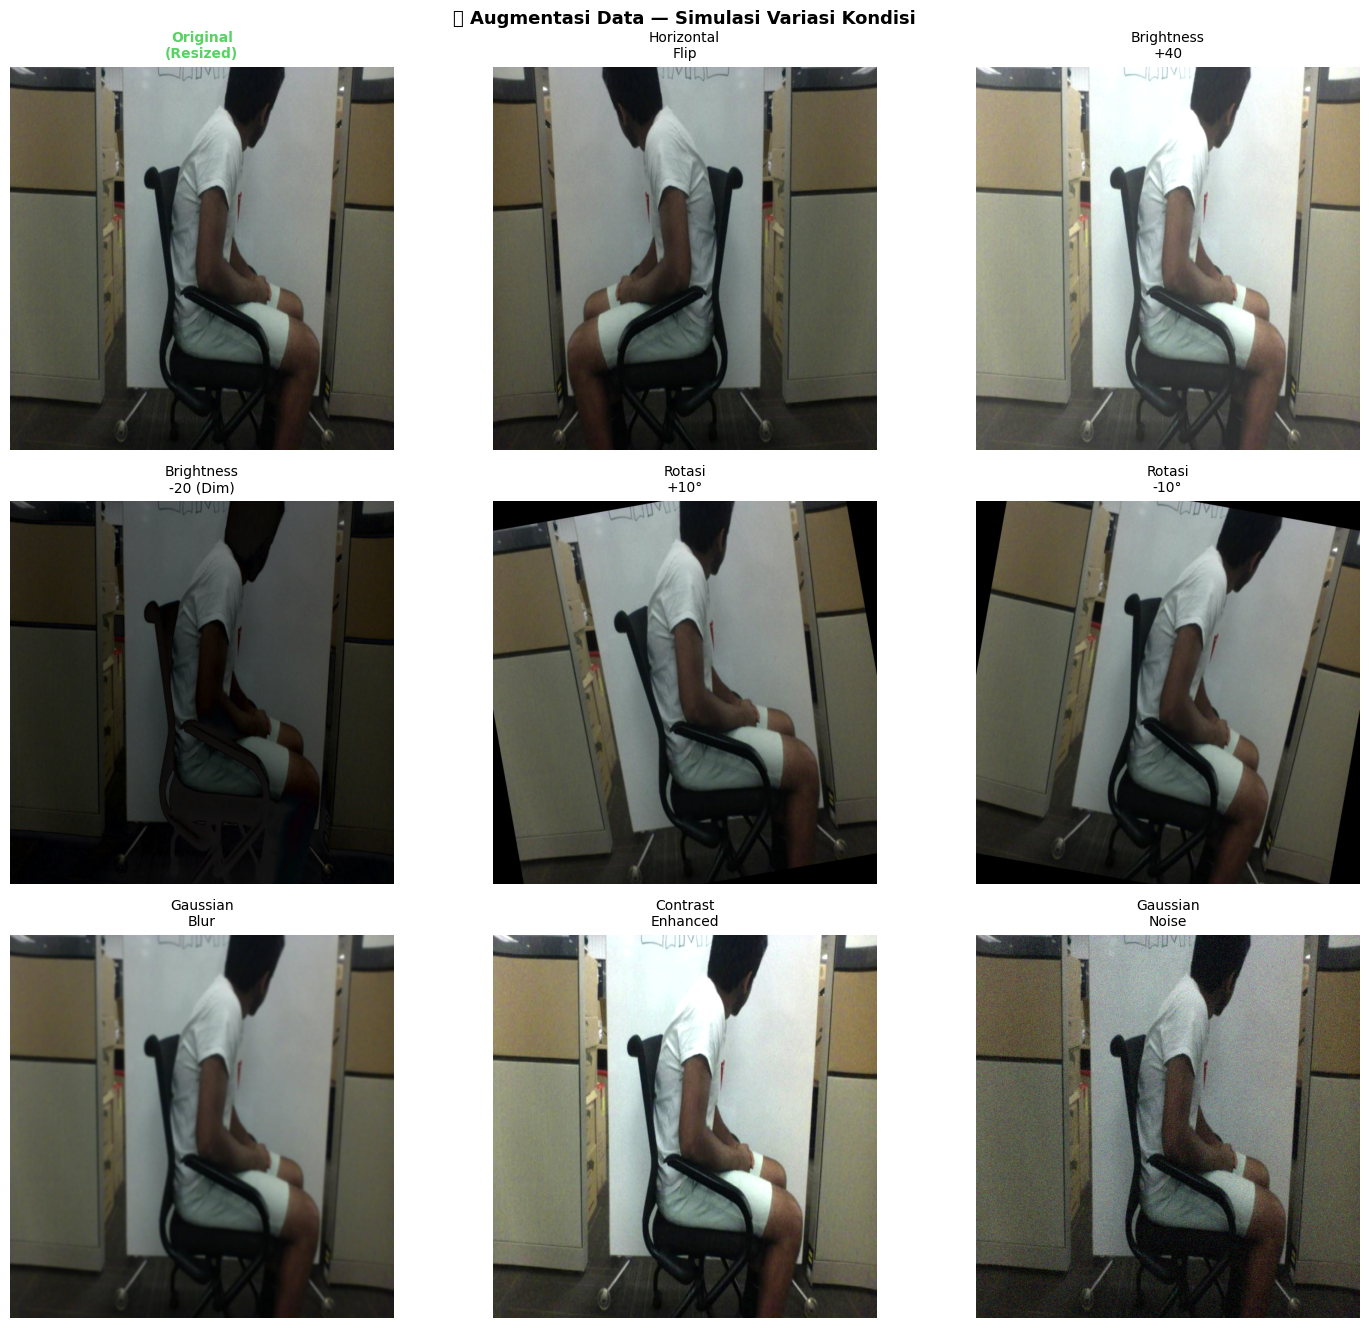

✅ 8 teknik augmentasi divisualisasikan
   (Dalam training YOLOv8, augmentasi dikonfigurasi otomatis via hyperparameter)


In [8]:
# ============================================================
# CELL 8: Preprocessing — Augmentasi Data (Visualisasi)
# ============================================================

def augment_image(img_rgb):
    """Kumpulan augmentasi untuk simulasi kondisi pencahayaan & orientasi berbeda."""
    results = {}

    # 1. Horizontal Flip
    results['Horizontal\nFlip'] = cv2.flip(img_rgb, 1)

    # 2. Brightness (terang)
    bright = cv2.convertScaleAbs(img_rgb, alpha=1.3, beta=40)
    results['Brightness\n+40'] = bright

    # 3. Brightness (gelap)
    dark = cv2.convertScaleAbs(img_rgb, alpha=0.6, beta=-20)
    results['Brightness\n-20 (Dim)'] = dark

    # 4. Rotasi ringan +10°
    h, w = img_rgb.shape[:2]
    M = cv2.getRotationMatrix2D((w//2, h//2), 10, 1.0)
    results['Rotasi\n+10°'] = cv2.warpAffine(img_rgb, M, (w, h))

    # 5. Rotasi ringan -10°
    M2 = cv2.getRotationMatrix2D((w//2, h//2), -10, 1.0)
    results['Rotasi\n-10°'] = cv2.warpAffine(img_rgb, M2, (w, h))

    # 6. Gaussian Blur (simulasi kamera buram)
    results['Gaussian\nBlur'] = cv2.GaussianBlur(img_rgb, (7, 7), 0)

    # 7. Contrast Enhancement
    results['Contrast\nEnhanced'] = cv2.convertScaleAbs(img_rgb, alpha=1.5, beta=0)

    # 8. Gaussian Noise
    noise = np.random.normal(0, 15, img_rgb.shape).astype(np.int16)
    noisy = np.clip(img_rgb.astype(np.int16) + noise, 0, 255).astype(np.uint8)
    results['Gaussian\nNoise'] = noisy

    return results

# Gunakan sample gambar dari Cell 8
img_resized_aug = cv2.resize(img_orig, (TARGET_SIZE, TARGET_SIZE))
augmented = augment_image(img_resized_aug)

n = len(augmented) + 1  # +1 untuk original
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 4.5))
axes = axes.flatten()

axes[0].imshow(img_resized_aug)
axes[0].set_title('Original\n(Resized)', fontsize=10, color='#56d364', fontweight='bold')
axes[0].axis('off')

for i, (aug_name, aug_img) in enumerate(augmented.items(), start=1):
    axes[i].imshow(aug_img)
    axes[i].set_title(aug_name, fontsize=10)
    axes[i].axis('off')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle("🎨 Augmentasi Data — Simulasi Variasi Kondisi", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"✅ {len(augmented)} teknik augmentasi divisualisasikan")
print("   (Dalam training YOLOv8, augmentasi dikonfigurasi otomatis via hyperparameter)")

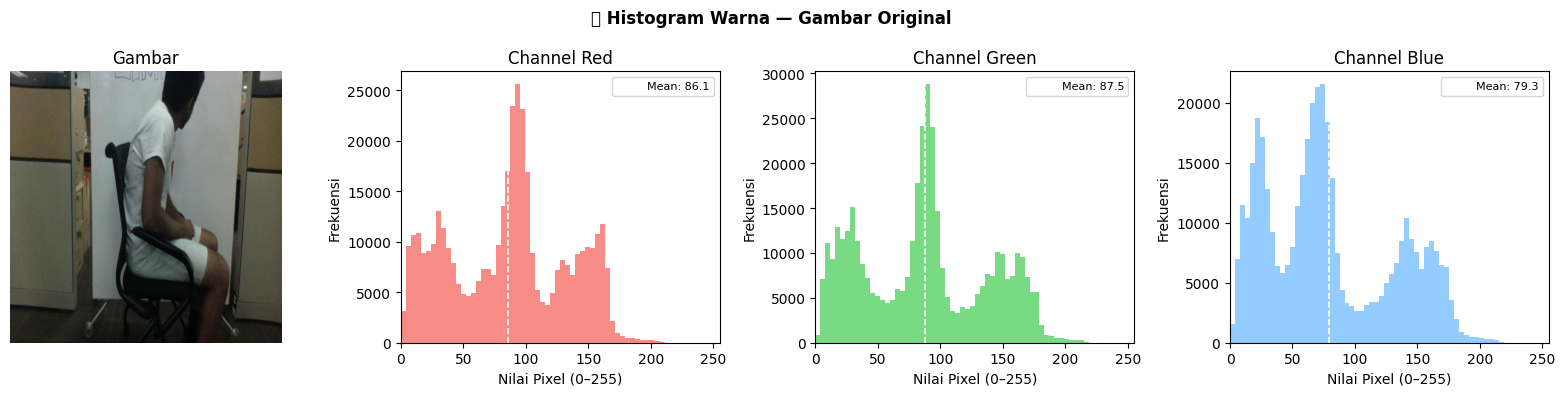

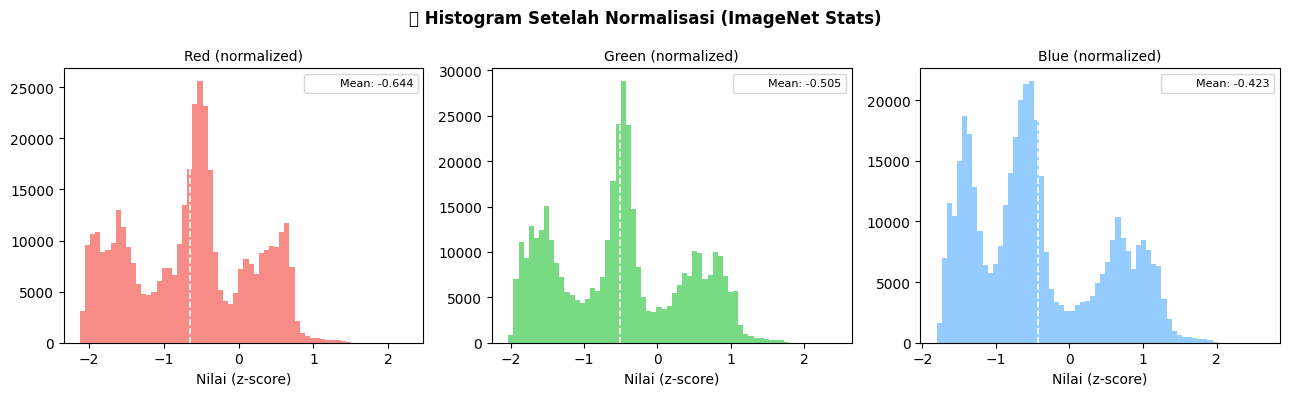

In [9]:
# ============================================================
# CELL 9: Preprocessing — Histogram Distribusi Warna RGB
# ============================================================

def plot_rgb_histogram(img_rgb, title="Histogram RGB"):
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    
    # Gambar asli
    axes[0].imshow(img_rgb)
    axes[0].set_title('Gambar')
    axes[0].axis('off')

    channel_info = [
        ('Red',   img_rgb[:,:,0], '#f47067'),
        ('Green', img_rgb[:,:,1], '#56d364'),
        ('Blue',  img_rgb[:,:,2], '#79c0ff'),
    ]

    for ax, (name, ch, color) in zip(axes[1:], channel_info):
        ax.hist(ch.flatten(), bins=64, color=color, alpha=0.8, edgecolor='none')
        ax.set_title(f'Channel {name}')
        ax.set_xlabel('Nilai Pixel (0–255)')
        ax.set_ylabel('Frekuensi')
        ax.set_xlim([0, 255])
        ax.axvline(ch.mean(), color='white', linestyle='--', linewidth=1.2,
                   label=f'Mean: {ch.mean():.1f}')
        ax.legend(fontsize=8)

    plt.suptitle(title, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()


# Histogram Original
plot_rgb_histogram(img_resized_aug, "📊 Histogram Warna — Gambar Original")

# Histogram setelah Normalisasi ImageNet
MEAN = np.array([0.485, 0.456, 0.406])
STD  = np.array([0.229, 0.224, 0.225])
img_float = img_resized_aug.astype(np.float32) / 255.0
img_normalized = (img_float - MEAN) / STD

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
channel_names = ['Red (normalized)', 'Green (normalized)', 'Blue (normalized)']
colors = ['#f47067', '#56d364', '#79c0ff']

for i, (name, color) in enumerate(zip(channel_names, colors)):
    axes[i].hist(img_normalized[:,:,i].flatten(), bins=64, color=color, alpha=0.8)
    axes[i].set_title(name, fontsize=10)
    axes[i].set_xlabel('Nilai (z-score)')
    axes[i].axvline(img_normalized[:,:,i].mean(), color='white',
                    linestyle='--', linewidth=1.2,
                    label=f'Mean: {img_normalized[:,:,i].mean():.3f}')
    axes[i].legend(fontsize=8)

plt.suptitle("📊 Histogram Setelah Normalisasi (ImageNet Stats)", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
# ============================================================
# CELL 10: Ringkasan Akhir Preprocessing
# ============================================================

print("=" * 55)
print("  ✅  PREPROCESSING SELESAI — RINGKASAN")
print("=" * 55)

summary = {
    'Input Size (Target)': f'{TARGET_SIZE} × {TARGET_SIZE} px',
    'Normalisasi':          'ImageNet Mean/Std (0–1 range)',
    'Augmentasi':           'Flip, Brightness, Rotasi ±10°, Blur, Noise',
    'Total Kelas':          len(CLASS_NAMES),
    'Nama Kelas':           ', '.join(CLASS_NAMES.values()),
    'Format Label':         'YOLOv8 (XYWH Normalized)',
    'Config File':          str(yaml_path),
}

df_summary = pd.DataFrame(list(summary.items()), columns=['Parameter', 'Value'])
print(df_summary.to_string(index=False))

print("\n📁 DATA SPLIT:")
split_df = pd.DataFrame({
    'Split': ['Train', 'Valid', 'Test'],
    'Jumlah Gambar': [train_count, valid_count, test_count],
    'Proporsi (%)': [
        round(train_count / total * 100, 1) if total else 0,
        round(valid_count / total * 100, 1) if total else 0,
        round(test_count  / total * 100, 1) if total else 0,
    ]
})
print(split_df.to_string(index=False))
print("=" * 55)

  ✅  PREPROCESSING SELESAI — RINGKASAN
          Parameter                                      Value
Input Size (Target)                               640 × 640 px
        Normalisasi              ImageNet Mean/Std (0–1 range)
         Augmentasi Flip, Brightness, Rotasi ±10°, Blur, Noise
        Total Kelas                                          3
         Nama Kelas    Good Posture, Mild Fatigue, Bad Posture
       Format Label                   YOLOv8 (XYWH Normalized)
        Config File               D:\cv-posture\data\data.yaml

📁 DATA SPLIT:
Split  Jumlah Gambar  Proporsi (%)
Train           4034          92.5
Valid            282           6.5
 Test             47           1.1


In [11]:
# ============================================================
# CELL 11: Load Model YOLOv8-Pose & Cek GPU
# ============================================================
import torch
from ultralytics import YOLO

# --- Paksa gunakan CUDA (RTX 3050), bukan CPU/iGPU ---
if not torch.cuda.is_available():
    raise EnvironmentError("❌ CUDA tidak terdeteksi! Pastikan PyTorch versi CUDA sudah terinstall.")

DEVICE = "cuda:0"  # cuda:0 = GPU pertama (RTX kamu)

# Detail GPU
gpu = torch.cuda.get_device_properties(0)
print("=" * 50)
print("  GPU INFO")
print("=" * 50)
print(f"  Nama GPU       : {gpu.name}")
print(f"  Total VRAM     : {gpu.total_memory / 1e9:.2f} GB")
print(f"  CUDA Version   : {torch.version.cuda}")
print(f"  Device yg dipakai : {DEVICE}")
print("=" * 50)

# Load YOLOv8 pretrained (nano = ringan, cocok untuk fine-tune)
# Opsi model: yolov8n.pt | yolov8s.pt | yolov8m.pt
# Untuk RTX 3050 (4GB VRAM) → pakai 's' agar balance speed & akurasi
model = YOLO("yolov8s.pt")  # otomatis download jika belum ada

print("\n✅ Model YOLOv8s berhasil dimuat!")
print(f"   Task   : {model.task}")
print(f"   Device : akan dijalankan di {DEVICE}")

  GPU INFO
  Nama GPU       : NVIDIA GeForce RTX 3050 Laptop GPU
  Total VRAM     : 4.29 GB
  CUDA Version   : 11.8
  Device yg dipakai : cuda:0

✅ Model YOLOv8s berhasil dimuat!
   Task   : detect
   Device : akan dijalankan di cuda:0


In [ ]:
# ============================================================
# CELL 12: Konfigurasi Hyperparameter Training
# ============================================================
import pandas as pd

# ---------------------------------------------------------------
# STRATEGI ANTI-OVERFITTING:
# 1. Epoch moderat (50) + early stopping (patience=15)
#    → training berhenti otomatis jika val/loss tidak membaik
# 2. Dropout aktif via close_mosaic & augmentasi bawaan YOLO
# 3. Weight decay (0.0005) → L2 regularisasi
# 4. Image augmentation (mosaic, flipud, hsv) dari YOLO default
# 5. Batch size 16 → stabil di VRAM 4GB RTX 3050
# ---------------------------------------------------------------

TRAIN_CONFIG = {
    # --- Path ---
    "data"          : str(YAML_PATH),
    "project"       : str(BASE_DIR / "runs"),
    "name"          : "posture_yolov8s",

    # --- Device ---
    "device"        : 0,            # 0 = cuda:0 (RTX kamu), bukan 'cpu'

    # --- Epoch & Batch ---
    "epochs"        : 15,           # moderat; early stopping akan potong lebih awal
    "patience"      : 5,           # stop jika 15 epoch berturut tidak ada improvement
    "batch"         : 16,           # aman untuk VRAM 4GB; turunkan ke 8 jika OOM

    # --- Ukuran Input ---
    "imgsz"         : 640,

    # --- Optimizer ---
    "optimizer"     : "AdamW",      # AdamW lebih stabil vs SGD untuk fine-tuning
    "lr0"           : 0.001,        # learning rate awal
    "lrf"           : 0.01,         # lr akhir = lr0 * lrf (cosine decay)
    "momentum"      : 0.937,
    "weight_decay"  : 0.0005,       # L2 regularisasi → tekan overfitting

    # --- Warmup ---
    "warmup_epochs" : 3,            # 3 epoch pertama lr naik perlahan
    "warmup_bias_lr": 0.1,

    # --- Augmentasi (anti-overfitting) ---
    "mosaic"        : 1.0,          # mosaic augmentation
    "mixup"         : 0.1,          # mixup antar gambar
    "flipud"        : 0.3,          # flip vertikal 30%
    "fliplr"        : 0.5,          # flip horizontal 50%
    "hsv_h"         : 0.015,        # variasi hue
    "hsv_s"         : 0.7,          # variasi saturasi
    "hsv_v"         : 0.4,          # variasi brightness
    "close_mosaic"  : 10,           # matikan mosaic di 10 epoch terakhir (stabilkan)

    # --- Logging ---
    "plots"         : True,         # simpan grafik metrik otomatis
    "save"          : True,
    "save_period"   : 10,           # simpan checkpoint tiap 10 epoch
    "val"           : True,
    "verbose"       : True,
}

# Tampilkan tabel konfigurasi
df_cfg = pd.DataFrame(list(TRAIN_CONFIG.items()), columns=["Parameter", "Value"])
print("⚙️  KONFIGURASI TRAINING:")
print(df_cfg.to_string(index=False))
print(f"\n🎯 Strategi: Early Stopping patience={TRAIN_CONFIG['patience']} epoch")
print(f"   → Training otomatis berhenti jika val tidak membaik dalam {TRAIN_CONFIG['patience']} epoch berturut")

⚙️  KONFIGURASI TRAINING:
     Parameter                        Value
          data D:\cv-posture\data\data.yaml
       project           D:\cv-posture\runs
          name              posture_yolov8s
        device                            0
        epochs                           50
      patience                           15
         batch                           16
         imgsz                          640
     optimizer                        AdamW
           lr0                        0.001
           lrf                         0.01
      momentum                        0.937
  weight_decay                       0.0005
 warmup_epochs                            3
warmup_bias_lr                          0.1
        mosaic                          1.0
         mixup                          0.1
        flipud                          0.3
        fliplr                          0.5
         hsv_h                        0.015
         hsv_s                          0.7
      

In [13]:
# ============================================================
# CELL 13: Training YOLOv8-Pose
# ============================================================

print("🚀 Memulai training...")
print(f"   Model  : YOLOv8s")
print(f"   Device : GPU cuda:0 ({torch.cuda.get_device_name(0)})")
print(f"   Epochs : maks {TRAIN_CONFIG['epochs']} (early stop patience={TRAIN_CONFIG['patience']})")
print(f"   Batch  : {TRAIN_CONFIG['batch']}")
print("=" * 55)

results = model.train(**TRAIN_CONFIG)

print("\n✅ Training selesai!")
print(f"   Best model tersimpan di: {results.save_dir}/weights/best.pt")

🚀 Memulai training...
   Model  : YOLOv8s
   Device : GPU cuda:0 (NVIDIA GeForce RTX 3050 Laptop GPU)
   Epochs : maks 50 (early stop patience=15)
   Batch  : 16
Ultralytics 8.4.48  Python-3.10.6 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:\cv-posture\data\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.3, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, m

KeyboardInterrupt: 

In [ ]:
# ============================================================
# CELL 14: Visualisasi Loss & Metrik Curve dari Hasil Training
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pandas as pd
from pathlib import Path

SAVE_DIR = Path(results.save_dir)

# --- 1. Baca results.csv yang di-generate YOLO otomatis ---
csv_path = SAVE_DIR / "results.csv"

if csv_path.exists():
    df_res = pd.read_csv(csv_path)
    df_res.columns = df_res.columns.str.strip()  # hapus spasi di nama kolom

    epochs_done = len(df_res)
    print(f"📊 Training berjalan selama: {epochs_done} epoch")
    print(f"   (dari maks {TRAIN_CONFIG['epochs']}, early stop aktif)\n")

    fig, axes = plt.subplots(2, 3, figsize=(17, 9))
    axes = axes.flatten()

    plot_targets = [
        ("train/box_loss",  "Train Box Loss",     "#4C9BE8"),
        ("train/cls_loss",  "Train Class Loss",   "#f0883e"),
        ("train/dfl_loss",  "Train DFL Loss",     "#d2a8ff"),
        ("val/box_loss",    "Val Box Loss",        "#56d364"),
        ("val/cls_loss",    "Val Class Loss",      "#f47067"),
        ("metrics/mAP50(B)","mAP@50",             "#ffa657"),
    ]

    for ax, (col, title, color) in zip(axes, plot_targets):
        if col in df_res.columns:
            ax.plot(df_res.index + 1, df_res[col], color=color, linewidth=2)
            ax.set_title(title, fontsize=11, fontweight='bold')
            ax.set_xlabel("Epoch")
            ax.set_ylabel("Value")
            ax.grid(True, alpha=0.3)
            # Tandai nilai terbaik
            best_val = df_res[col].min() if "loss" in col else df_res[col].max()
            best_ep  = df_res[col].idxmin() + 1 if "loss" in col else df_res[col].idxmax() + 1
            ax.axvline(best_ep, linestyle='--', color='white', alpha=0.5, linewidth=1)
            ax.scatter(best_ep, best_val, color='white', zorder=5, s=50)
            ax.annotate(f"Best: {best_val:.4f}\n(ep {best_ep})",
                        xy=(best_ep, best_val),
                        xytext=(8, 8), textcoords='offset points',
                        fontsize=8, color='white')
        else:
            ax.set_visible(False)

    plt.suptitle("📈 Training & Validation Curves", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # --- 2. Tabel ringkasan epoch terbaik ---
    if "metrics/mAP50(B)" in df_res.columns:
        best_idx = df_res["metrics/mAP50(B)"].idxmax()
        best_row = df_res.iloc[best_idx]
        print("\n🏆 EPOCH TERBAIK (berdasarkan mAP@50):")
        print("=" * 45)
        for col in df_res.columns:
            if any(k in col for k in ["loss", "mAP", "precision", "recall"]):
                print(f"  {col.strip():30s}: {best_row[col]:.4f}")
        print("=" * 45)

else:
    print("⚠️  results.csv tidak ditemukan. Pastikan training sudah selesai.")

In [ ]:
# ============================================================
# CELL 15: Confusion Matrix & Sample Prediksi dari Validasi
# ============================================================

# --- 1. Confusion Matrix (di-generate YOLO otomatis) ---
cm_path = SAVE_DIR / "confusion_matrix_normalized.png"
if not cm_path.exists():
    cm_path = SAVE_DIR / "confusion_matrix.png"

if cm_path.exists():
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.imshow(mpimg.imread(cm_path))
    ax.axis('off')
    ax.set_title("Confusion Matrix (Validation Set)", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("⚠️  Confusion matrix belum tersedia.")

# --- 2. Sample Prediksi di Validation Set ---
val_pred_dir = SAVE_DIR / "val_batch0_pred.jpg"
if not val_pred_dir.exists():
    # coba cari file pred lain
    preds = list(SAVE_DIR.glob("val_batch*_pred.jpg"))
    val_pred_dir = preds[0] if preds else None

if val_pred_dir and Path(val_pred_dir).exists():
    fig, ax = plt.subplots(figsize=(12, 7))
    ax.imshow(mpimg.imread(str(val_pred_dir)))
    ax.axis('off')
    ax.set_title("Sample Prediksi — Validation Batch", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("⚠️  Sample prediksi belum tersedia.")

In [ ]:
# ============================================================
# CELL 17: Ringkasan Akhir Training
# ============================================================

BEST_MODEL_PATH = SAVE_DIR / "weights" / "best.pt"
LAST_MODEL_PATH = SAVE_DIR / "weights" / "last.pt"

print("=" * 55)
print("  🏁  TRAINING SELESAI — RINGKASAN")
print("=" * 55)
print(f"  Model     : YOLOv8s")
print(f"  Device    : {torch.cuda.get_device_name(0)}")
print(f"  Epochs    : {epochs_done} / {TRAIN_CONFIG['epochs']} (early stop)")
print(f"  Batch     : {TRAIN_CONFIG['batch']}")
print(f"  Img Size  : {TRAIN_CONFIG['imgsz']}")
print(f"  Optimizer : {TRAIN_CONFIG['optimizer']}")
print(f"  Save Dir  : {SAVE_DIR}")
print(f"  best.pt   : {'✅ Ada' if BEST_MODEL_PATH.exists() else '❌ Tidak ditemukan'}")
print(f"  last.pt   : {'✅ Ada' if LAST_MODEL_PATH.exists() else '❌ Tidak ditemukan'}")
print("=" * 55)
print("\n🚀 Langkah selanjutnya: Feature Engineering — Ekstraksi Sudut Keypoints (Cell 18+)")